In [1]:
!pip install numpy
!pip install matplotlib

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
grid_size = 4

terminal_states = [(0,0), (3,3)]

actions = {
    0: (-1, 0),
    1: (1, 0),
    2: (0, -1),
    3: (0, 1)
}

gamma = 0.9

reward = -1V = np.zeros((grid_size, grid_size))


In [4]:
V = np.zeros((grid_size, grid_size))

print(V)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [5]:
def step(state, action):

    if state in terminal_states:
        return state, 0

    next_state = (
        state[0] + actions[action][0],
        state[1] + actions[action][1]
    )

    if next_state[0] < 0 or next_state[0] >= grid_size:
        next_state = state

    if next_state[1] < 0 or next_state[1] >= grid_size:
        next_state = state

    return next_state, reward

In [6]:
state = (1,1)

next_state, r = step(state, 3)

print("Current State:", state)
print("Next State:", next_state)
print("Reward:", r)

Current State: (1, 1)
Next State: (1, 2)
Reward: -1


In [7]:
theta = 0.0001

while True:

    delta = 0

    new_V = np.copy(V)

    for i in range(grid_size):

        for j in range(grid_size):

            state = (i,j)

            if state in terminal_states:
                continue

            value = 0

            for action in actions:

                next_state, r = step(state, action)

                value += 0.25 * (
                    r + gamma * V[next_state]
                )

            new_V[state] = value

            delta = max(delta, abs(V[state] - value))

    V = new_V

    if delta < theta:
        break

In [8]:
print("Optimal Value Function:")

print(np.round(V, 2))

Optimal Value Function:
[[ 0.   -5.28 -7.13 -7.65]
 [-5.28 -6.61 -7.18 -7.13]
 [-7.13 -7.18 -6.61 -5.28]
 [-7.65 -7.13 -5.28  0.  ]]


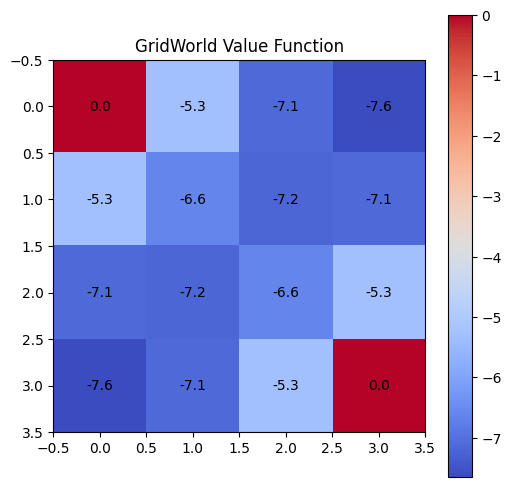

In [9]:
plt.figure(figsize=(6,6))

plt.imshow(V, cmap='coolwarm')

for i in range(grid_size):
    for j in range(grid_size):

        plt.text(
            j,
            i,
            round(V[i,j],1),
            ha='center',
            va='center',
            color='black'
        )

plt.colorbar()

plt.title("GridWorld Value Function")

plt.show()

In [10]:
policy = np.full((grid_size, grid_size), ' ')

symbols = {
    0: '↑',
    1: '↓',
    2: '←',
    3: '→'
}

for i in range(grid_size):

    for j in range(grid_size):

        state = (i,j)

        if state in terminal_states:
            policy[state] = 'G'
            continue

        action_values = []

        for action in actions:

            next_state, r = step(state, action)

            value = r + gamma * V[next_state]

            action_values.append(value)

        best_action = np.argmax(action_values)

        policy[state] = symbols[best_action]

print(policy)

[['G' '←' '←' '↓']
 ['↑' '↑' '←' '↓']
 ['↑' '↑' '↓' '↓']
 ['↑' '→' '→' 'G']]
